### Importations des livrairies


In [3]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)

print("Bibliothèques importées.")

Bibliothèques importées.


#### Chargement des donnees

In [2]:
data = pd.read_excel("orbit_dataset.xlsx")
data.columns = data.columns.str.strip()

print(data.shape)

data.head()
print("Données ont été chargées avec succès")

(116720, 26)
Données ont été chargées avec succès


#### Verifier les types

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116720 entries, 0 to 116719
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id_point                        116720 non-null  object 
 1   date_collecte                   116720 non-null  object 
 2   arrondissement                  116720 non-null  object 
 3   quartier                        116720 non-null  object 
 4   latitude                        116720 non-null  float64
 5   longitude                       116720 non-null  float64
 6   fillRate                        116720 non-null  float64
 7   fillRate_t_minus_1              116720 non-null  float64
 8   fillRate_t_minus_2              116720 non-null  float64
 9   delta_fillRate_24h              116720 non-null  float64
 10  rolling_mean_3d                 116720 non-null  float64
 11  fillRate_target_t_plus_1        116720 non-null  float64
 12  nb_signalements_

#### Puis convertisons la date :

In [5]:
data["date_collecte"] = pd.to_datetime(data["date_collecte"])

print("Date convertie.")


Date convertie.


In [6]:
print(data["date_collecte"].dtype) 

datetime64[ns]


#### Valeurs manquantes

In [7]:
missing = data.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [8]:
print("Aucune valeur manquante.") 

Aucune valeur manquante.


#### Détection des Doublons

In [11]:

print("Avant :", data.shape)

data = data.drop_duplicates()

print("Après :", data.shape)


Avant : (116720, 26)
Après : (116720, 26)


#### Vérification des valeurs aberrantes

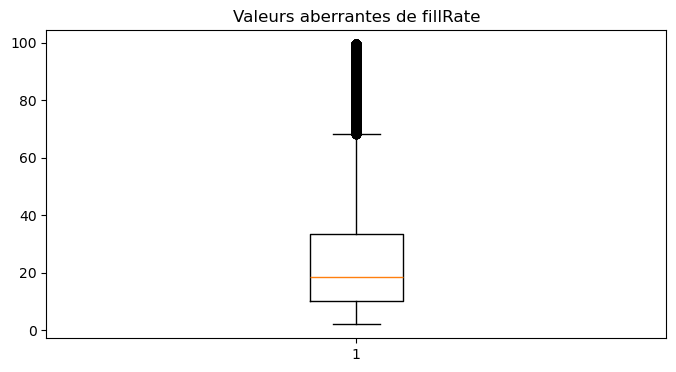

In [12]:

plt.figure(figsize=(8,4))

plt.boxplot(data["fillRate"])

plt.title("Valeurs aberrantes de fillRate")

plt.show()


#### Vérification des types

In [28]:
print(data.dtypes)

id_point                                   int64
date_collecte                     datetime64[ns]
latitude                                 float64
longitude                                float64
fillRate                                 float64
fillRate_t_minus_1                       float64
fillRate_t_minus_2                       float64
delta_fillRate_24h                       float64
rolling_mean_3d                          float64
fillRate_target_t_plus_1                 float64
nb_signalements_citoyens                   int64
nb_plaintes                                int64
nb_precollecteurs_dispo                    int64
jours_depuis_derniere_collecte             int64
capacity_m3                                int64
poids_kg                                 float64
densite_population_hab_km2                 int64
jour_semaine_num                           int64
is_weekend                                 int64
is_jour_marche                             int64
temperature_celsius 

#### Vérification de la variable cible

In [29]:
print(data["fillRate_target_t_plus_1"].describe())

count    116720.000000
mean         23.949255
std          18.385681
min           2.000000
25%          10.230000
50%          18.410000
75%          33.490000
max          99.500000
Name: fillRate_target_t_plus_1, dtype: float64


#### Vérification des variables numériques

In [30]:
print(data.select_dtypes(include=["number"]).columns)

Index(['id_point', 'latitude', 'longitude', 'fillRate', 'fillRate_t_minus_1',
       'fillRate_t_minus_2', 'delta_fillRate_24h', 'rolling_mean_3d',
       'fillRate_target_t_plus_1', 'nb_signalements_citoyens', 'nb_plaintes',
       'nb_precollecteurs_dispo', 'jours_depuis_derniere_collecte',
       'capacity_m3', 'poids_kg', 'densite_population_hab_km2',
       'jour_semaine_num', 'is_weekend', 'is_jour_marche',
       'temperature_celsius', 'humidite_pct', 'statut_prevu',
       'priorite_recommandee'],
      dtype='object')


#### Vérification des corrélations

In [31]:
correlation = data.corr(numeric_only=True)

print(correlation["fillRate_target_t_plus_1"].sort_values(ascending=False))


fillRate_target_t_plus_1          1.000000
statut_prevu                      0.849539
priorite_recommandee              0.832968
fillRate                          0.448683
jours_depuis_derniere_collecte    0.384874
poids_kg                          0.351719
delta_fillRate_24h                0.282743
rolling_mean_3d                   0.281957
fillRate_t_minus_1                0.151774
nb_signalements_citoyens          0.125493
is_weekend                        0.074497
longitude                         0.065745
latitude                          0.060865
jour_semaine_num                  0.059991
densite_population_hab_km2        0.052234
quartier_9                        0.047729
quartier_12                       0.045982
quartier_11                       0.042214
fillRate_t_minus_2                0.036234
quartier_1                        0.029050
nb_plaintes                       0.027926
quartier_2                        0.023694
is_jour_marche                    0.021243
arrondissem

### Feature Engineering avancé

#### Ici, nous créons de nouvelles variables permettant d'améliorer la prédiction de :.

#### Rendement de remplissage

In [32]:

data["rendement_remplissage"] = (
    data["poids_kg"] /
    data["capacity_m3"]
)

print("rendement_remplissage créé")

rendement_remplissage créé


#### Pression citoyenne

In [33]:
data["pression_citoyenne"] = (
    data["nb_signalements_citoyens"]
    +
    data["nb_plaintes"]
)

print("pression_citoyenne créée")

pression_citoyenne créée


#### Ratio plaintes

In [34]:
data["ratio_plaintes"] = (
    data["nb_plaintes"] /
    (data["nb_signalements_citoyens"] + 1)
)

print("ratio_plaintes créé")

ratio_plaintes créé



#### Indice météo


In [35]:
data["indice_meteo"] = (
    data["temperature_celsius"]
    *
    data["humidite_pct"]
)

print("indice_meteo créé")

indice_meteo créé


#### Pression opérationnelle


In [36]:
data["pression_collecte"] = (
    data["fillRate"]
    *
    data["jours_depuis_derniere_collecte"]
)

print("pression_collecte créée")

pression_collecte créée


#### Charge précollecteur

In [37]:

data["charge_precollecteur"] = (
    data["fillRate"] /
    (data["nb_precollecteurs_dispo"] + 1)
)

print("charge_precollecteur créée")

charge_precollecteur créée


#### Indice saturation

In [38]:

data["indice_saturation"] = (
    data["fillRate"]
    *
    data["densite_population_hab_km2"]
)

print("indice_saturation créé")

indice_saturation créé


#### Priorité intervention

In [39]:
data["indice_priorite"] = (
    data["pression_citoyenne"]
    *
    data["fillRate"]
)

print("indice_priorite créé")

indice_priorite créé


#### Risque débordement

In [40]:

data["risque_debordement"] = (
    data["fillRate"]
    *
    data["rolling_mean_3d"]
)

print("risque_debordement créé")

risque_debordement créé


#### Vérifications

In [41]:
print("Dimensions finales :")
print(data.shape)

data.head()



Dimensions finales :
(116720, 51)


,id_point,date_collecte,latitude,longitude,fillRate,fillRate_t_minus_1,fillRate_t_minus_2,delta_fillRate_24h,rolling_mean_3d,fillRate_target_t_plus_1,nb_signalements_citoyens,nb_plaintes,nb_precollecteurs_dispo,jours_depuis_derniere_collecte,capacity_m3,poids_kg,densite_population_hab_km2,jour_semaine_num,is_weekend,is_jour_marche,temperature_celsius,humidite_pct,statut_prevu,priorite_recommandee,arrondissement_1,arrondissement_2,arrondissement_3,arrondissement_4,quartier_1,quartier_2,quartier_3,quartier_4,quartier_5,quartier_6,quartier_7,quartier_8,quartier_9,quartier_10,quartier_11,quartier_12,quartier_13,quartier_14,rendement_remplissage,pression_citoyenne,ratio_plaintes,indice_meteo,pression_collecte,charge_precollecteur,indice_saturation,indice_priorite,risque_debordement
0,0,2022-01-03,4.001501,9.73807,49.55,33.98,12.98,15.58,32.17,6.00,0,0,2,2,7,933.30,18342,0,0,0,27.3,62.8,0,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,133.328571,0,0.0,1714.44,99.10,16.516667,908846.10,0.0,1594.0235
1,0,2022-01-04,4.001501,9.73807,6.00,49.55,33.98,-43.56,29.84,21.43,0,0,1,0,7,107.60,18342,1,0,1,29.7,69.1,0,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,15.371429,0,0.0,2052.27,0.00,3.000000,110052.00,0.0,179.0400
2,0,2022-01-05,4.001501,9.73807,21.43,6.00,49.55,15.43,25.66,36.56,0,0,1,1,7,388.04,18342,2,0,0,28.6,67.0,0,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,55.434286,0,0.0,1916.20,21.43,10.715000,393069.06,0.0,549.8938
3,0,2022-01-06,4.001501,9.73807,36.56,21.43,6.00,15.13,21.33,52.21,0,0,3,2,7,673.95,18342,3,0,0,30.2,70.8,1,2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,96.278571,0,0.0,2138.16,73.12,9.140000,670583.52,0.0,779.8248
4,0,2022-01-07,4.001501,9.73807,52.21,36.56,21.43,15.65,36.73,72.72,0,0,3,3,7,979.65,18342,4,0,0,28.4,61.3,2,3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,139.950000,0,0.0,1740.92,156.63,13.052500,957635.82,0.0,1917.6733


### Vérifions les valeurs manquantes Valeurs manquantes

In [42]:

print(
    data.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

id_point                    0
date_collecte               0
latitude                    0
longitude                   0
fillRate                    0
fillRate_t_minus_1          0
fillRate_t_minus_2          0
delta_fillRate_24h          0
rolling_mean_3d             0
fillRate_target_t_plus_1    0
dtype: int64


#### les Statistiques

In [43]:
data.describe()

,id_point,date_collecte,latitude,longitude,fillRate,fillRate_t_minus_1,fillRate_t_minus_2,delta_fillRate_24h,rolling_mean_3d,fillRate_target_t_plus_1,nb_signalements_citoyens,nb_plaintes,nb_precollecteurs_dispo,jours_depuis_derniere_collecte,capacity_m3,poids_kg,densite_population_hab_km2,jour_semaine_num,is_weekend,is_jour_marche,temperature_celsius,humidite_pct,statut_prevu,priorite_recommandee,rendement_remplissage,pression_citoyenne,ratio_plaintes,indice_meteo,pression_collecte,charge_precollecteur,indice_saturation,indice_priorite,risque_debordement
count,116720.000000,116720,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,1.167200e+05,116720.000000,116720.000000
mean,39.500000,2024-01-02 00:00:00,4.045566,9.702375,23.951267,23.955521,23.955589,-0.004248,23.954139,23.949255,0.059236,0.006083,3.739659,1.526405,17.062500,1142.295990,14500.812500,2.995888,0.285127,0.142735,27.497669,75.006430,0.213340,0.388862,67.058597,0.065319,0.004204,2047.534158,64.375819,6.993279,3.534538e+05,4.354230,754.151334
min,0.000000,2022-01-03 00:00:00,3.940558,9.570896,2.000000,2.000000,2.000000,-97.380000,2.340000,2.000000,0.000000,0.000000,0.000000,0.000000,5.000000,23.360000,3982.000000,0.000000,0.000000,0.000000,21.000000,40.400000,0.000000,0.000000,4.585556,0.000000,0.000000,1248.360000,0.000000,0.251250,8.202920e+03,0.000000,5.499000
25%,19.750000,2023-01-02 00:00:00,4.010506,9.674735,10.230000,10.230000,10.230000,-4.242500,13.540000,10.230000,0.000000,0.000000,2.000000,0.000000,9.000000,367.007500,8332.000000,1.000000,0.000000,0.000000,26.200000,65.100000,0.000000,0.000000,28.566188,0.000000,0.000000,1871.100000,0.000000,1.940000,1.107884e+05,0.000000,151.484300
50%,39.500000,2024-01-02 00:00:00,4.044230,9.698916,18.410000,18.410000,18.420000,6.910000,20.260000,18.410000,0.000000,0.000000,4.000000,1.000000,16.500000,768.995000,15512.500000,3.000000,0.000000,0.000000,27.500000,75.000000,0.000000,0.000000,51.350652,0.000000,0.000000,2051.900000,19.420000,3.946667,2.359034e+05,0.000000,344.350750
75%,59.250000,2025-01-01 00:00:00,4.075389,9.730496,33.490000,33.510000,33.510000,11.130000,31.190000,33.490000,0.000000,0.000000,5.000000,2.000000,24.250000,1496.552500,20172.000000,5.000000,1.000000,0.000000,28.800000,85.000000,0.000000,0.000000,93.705598,0.000000,0.000000,2222.220000,78.560000,8.510000,4.829448e+05,0.000000,828.059350
max,79.000000,2025-12-31 00:00:00,4.179424,9.800674,99.500000,99.500000,99.500000,36.810000,99.500000,99.500000,6.000000,3.000000,7.000000,14.000000,30.000000,8709.310000,24761.000000,6.000000,1.000000,1.000000,34.400000,99.000000,3.000000,3.000000,317.085000,7.000000,2.000000,2920.500000,1293.500000,99.500000,2.396856e+06,619.920000,9900.250000
std,23.092305,NaN,0.048222,0.044429,18.388678,18.390353,18.388312,19.309115,13.841490,18.385681,0.293383,0.083392,1.808506,1.741757,8.290608,1128.284449,6402.086332,2.000347,0.451477,0.349804,1.790202,11.329674,0.481395,0.832518,51.657574,0.319652,0.061607,231.676917,106.510332,8.954446,3.402066e+05,22.918973,1075.725732


#### Sauvegarde dataset final

In [48]:
import os

print(os.getcwd())

C:\Users\LENOVO\Documents\Soutenance\Project_soutenance


In [49]:
import os

os.makedirs("data/processed", exist_ok=True)

data.to_excel(
    "data/processed/orbit_dataset_engineering.xlsx",
    index=False
)

print("Fichier enregistré.")

Fichier enregistré.
